In [119]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [120]:
# encoding='latin-1': Prevent errors caused by reading strange symbols and currency markings found in messages
df = pd.read_csv('spam.csv', encoding='latin-1')

In [121]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [123]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [124]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ahmad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ahmad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ahmad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ahmad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [125]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [126]:
def clean_text(text):
    text = str(text).lower()  
    #[a-z\s] means: letters and spaces 
    # \s : Space
    # ^   means: not
    text = re.sub(r'[^a-z\s]', '', text)  
    tokens = word_tokenize(text)  
    # Remove stop words and reduce the remaining words to their base form (lemma)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words] 
    return " ".join(tokens)

In [127]:
df['clean_message'] = df['message'].apply(clean_text)

In [128]:
# TF-IDF Vectorization: Extracts the top 5000 unique words and converts text messages into numeric feature weights
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
# fit: Builds the vocabulary (dictionary) | transform: Converts text to numbers based on that vocabulary
X = tfidf_vectorizer.fit_transform(df['clean_message'])
y = df['label']

In [129]:
# Splits data: 80% for training the model and 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [130]:
# Naive Bayes model and trains it using the training dataset
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [131]:

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Overall Accuracy: {accuracy:.4f}\n")
print("Detailed Classification Report:")
# macro avg: Simple average (treats classes equally) | weighted avg: Mapped average based on class sizes
print(classification_report(y_test, y_pred))


Model Overall Accuracy: 0.9731

Detailed Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       965
        spam       1.00      0.80      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



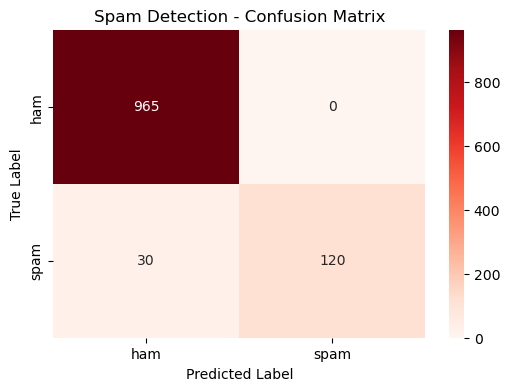

In [132]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Spam Detection - Confusion Matrix')
plt.show()

In [133]:
def predict_new_message(new_msg):
    cleaned = clean_text(new_msg)
    vectorized = tfidf_vectorizer.transform([cleaned]) # Uses 'transform' only (without fit) to apply the existing dictionary to the new message
    prediction = model.predict(vectorized)
    return prediction[0]

In [134]:
test_msg = "Congratulations! You've won a 1000 prize reward. Call now to claim your free gift."
print(f"Test Message: '{test_msg}'")
print(f"Model Prediction: {predict_new_message(test_msg)}")

Test Message: 'Congratulations! You've won a 1000 prize reward. Call now to claim your free gift.'
Model Prediction: spam
